# Exploratory Data Analysis: Online Retail Customer Churn

This notebook explores the Online Retail Customer Churn Prediction dataset from Kaggle.

**Dataset:** [Online Retail Customer Churn Prediction](https://www.kaggle.com/datasets/sahilislam007/online-retail-customer-churn-prediction-dataset)

In [27]:
# notebooks/exploratory_data_analysis.ipynb
# Cell 1: Import required libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [28]:
# Cell 2: Download dataset from Kaggle
# Note: You may need to authenticate with Kaggle first
# Run: kaggle config set -n username -v YOUR_USERNAME
#      kaggle config set -n key -v YOUR_API_KEY
# Or set environment variables: KAGGLE_USERNAME and KAGGLE_KEY

# Download the latest version of the dataset
path = kagglehub.dataset_download("sahilislam007/online-retail-customer-churn-prediction-dataset")
print("Path to dataset files:", path)

Path to dataset files: /Users/matiascam/.cache/kagglehub/datasets/sahilislam007/online-retail-customer-churn-prediction-dataset/versions/1


In [29]:
# Cell 3: List downloaded files and load the dataset

# List all files in the downloaded directory
print("Files in dataset directory:")
for file in os.listdir(path):
    print(f"  - {file}")

# Find and load CSV file(s)
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(f"\nFound {len(csv_files)} CSV file(s): {csv_files}")

Files in dataset directory:
  - online_retail_customer_data_extended.csv

Found 1 CSV file(s): ['online_retail_customer_data_extended.csv']


In [30]:
# Cell 4: Load the main dataset into a DataFrame
# Assuming the primary file is the first CSV found

if csv_files:
    # Load the first CSV file (adjust if multiple files exist)
    file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(file_path)
    print(f"Loaded: {csv_files[0]}")
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
else:
    print("No CSV files found in the dataset directory.")

Loaded: online_retail_customer_data_extended.csv
Shape: 9000 rows x 17 columns


In [31]:
# Cell 5: Preview the data

# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,CustomerID,Age,Gender,Annual_Income_USD,Spending_Score,Membership_Status,Preferred_Payment_Method,Region,Total_Purchases,Avg_Purchase_Value,Last_Purchase_Date,Churn,Satisfaction_Score,Website_Visits_Last_Month,Avg_Time_Per_Visit_Minutes,Support_Tickets_Last_6_Months,Referred_Friends
0,2f8c8c58-4779-4006-aa23-81db3a352da3,56,Female,79228,73,Bronze,Cryptocurrency,Central,17,209.07,2025-05-01,0,2.3,7,3.01,0,1
1,4e6558a6-7f45-4f2a-8dfc-fb05210c5a54,69,Female,23205,65,Silver,Cryptocurrency,Central,21,25.60,2025-04-14,0,2.5,14,5.80,5,2
2,11ab8d14-6dd9-4a49-84cc-963431a8e6fc,46,Male,54929,68,Bronze,Debit Card,Central,25,105.48,2024-11-20,0,4.6,18,5.00,0,0
3,503e4ec0-42c7-4c2d-8cda-a480ad492b4b,32,Female,103384,71,Bronze,PayPal,Central,25,381.95,2024-08-22,1,4.9,20,5.98,5,0
4,841426ba-7371-43b1-9cba-036d07d6c85e,60,Male,53411,11,Silver,PayPal,West,24,319.19,2025-02-05,0,1.2,18,1.67,1,1


In [32]:
# Cell 6: Dataset info - data types, memory usage, and missing values

print("Dataset Info:")
print("=" * 50)
df.info()
print("\n")
print("Missing Values:")
print("=" * 50)
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     9000 non-null   str    
 1   Age                            9000 non-null   int64  
 2   Gender                         9000 non-null   str    
 3   Annual_Income_USD              9000 non-null   int64  
 4   Spending_Score                 9000 non-null   int64  
 5   Membership_Status              9000 non-null   str    
 6   Preferred_Payment_Method       9000 non-null   str    
 7   Region                         9000 non-null   str    
 8   Total_Purchases                9000 non-null   int64  
 9   Avg_Purchase_Value             9000 non-null   float64
 10  Last_Purchase_Date             9000 non-null   str    
 11  Churn                          9000 non-null   int64  
 12  Satisfaction_Score             9000 non-null 

In [33]:
# Cell 7: Descriptive statistics for numerical columns

print("Descriptive Statistics:")
print("=" * 50)
df.describe()

Descriptive Statistics:


,Age,Annual_Income_USD,Spending_Score,Total_Purchases,Avg_Purchase_Value,Churn,Satisfaction_Score,Website_Visits_Last_Month,Avg_Time_Per_Visit_Minutes,Support_Tickets_Last_6_Months,Referred_Friends
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,43.550444,84932.292222,49.764222,20.012889,254.048938,0.197333,2.999700,15.017444,4.992113,1.490778,0.822889
std,14.909264,37649.418701,28.693640,4.398710,142.397216,0.398008,1.149508,3.857794,1.974112,1.218867,0.922469
min,18.000000,20014.000000,1.000000,5.000000,10.070000,0.000000,1.000000,3.000000,0.500000,0.000000,0.000000
25%,31.000000,51436.000000,25.000000,17.000000,131.440000,0.000000,2.000000,12.000000,3.650000,1.000000,0.000000
50%,43.000000,85389.500000,49.000000,20.000000,251.950000,0.000000,3.000000,15.000000,4.990000,1.000000,1.000000
75%,56.000000,117357.000000,75.000000,23.000000,378.322500,0.000000,4.000000,17.000000,6.332500,2.000000,1.000000
max,69.000000,149997.000000,99.000000,40.000000,499.950000,1.000000,5.000000,32.000000,12.680000,8.000000,6.000000


## Target Variable Analysis

Let's examine the distribution of the target variable (Churn) to understand class balance.

Target Variable Distribution:
Not Churned (0): 7224 (80.3%)
Churned (1): 1776 (19.7%)

Churn Rate: 19.73%
Class Imbalance Ratio: 4.07:1


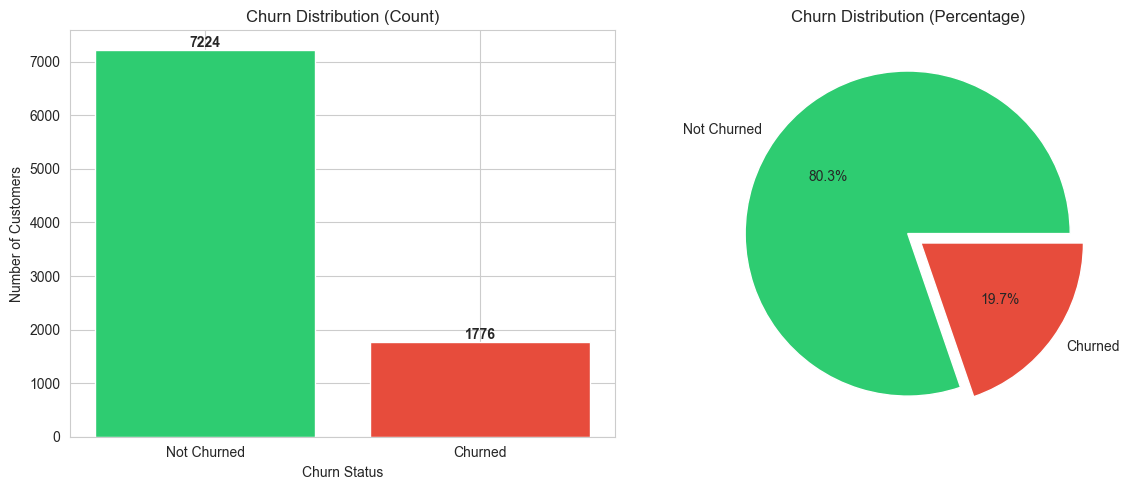

In [34]:
# Cell 8: Target variable distribution
# Analyze the churn rate and class imbalance

# Calculate churn statistics
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].mean() * 100

print("Target Variable Distribution:")
print("=" * 50)
print(f"Not Churned (0): {churn_counts[0]} ({100 - churn_rate:.1f}%)")
print(f"Churned (1): {churn_counts[1]} ({churn_rate:.1f}%)")
print(f"\nChurn Rate: {churn_rate:.2f}%")
print(f"Class Imbalance Ratio: {churn_counts[0] / churn_counts[1]:.2f}:1")

# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values, color=colors)
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Churn Distribution (Count)')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'], 
            autopct='%1.1f%%', colors=colors, explode=(0, 0.1))
axes[1].set_title('Churn Distribution (Percentage)')

plt.tight_layout()
plt.show()

## Numerical Feature Distribution

Let's analyze the distribution of numerical features and their relationship with churn.

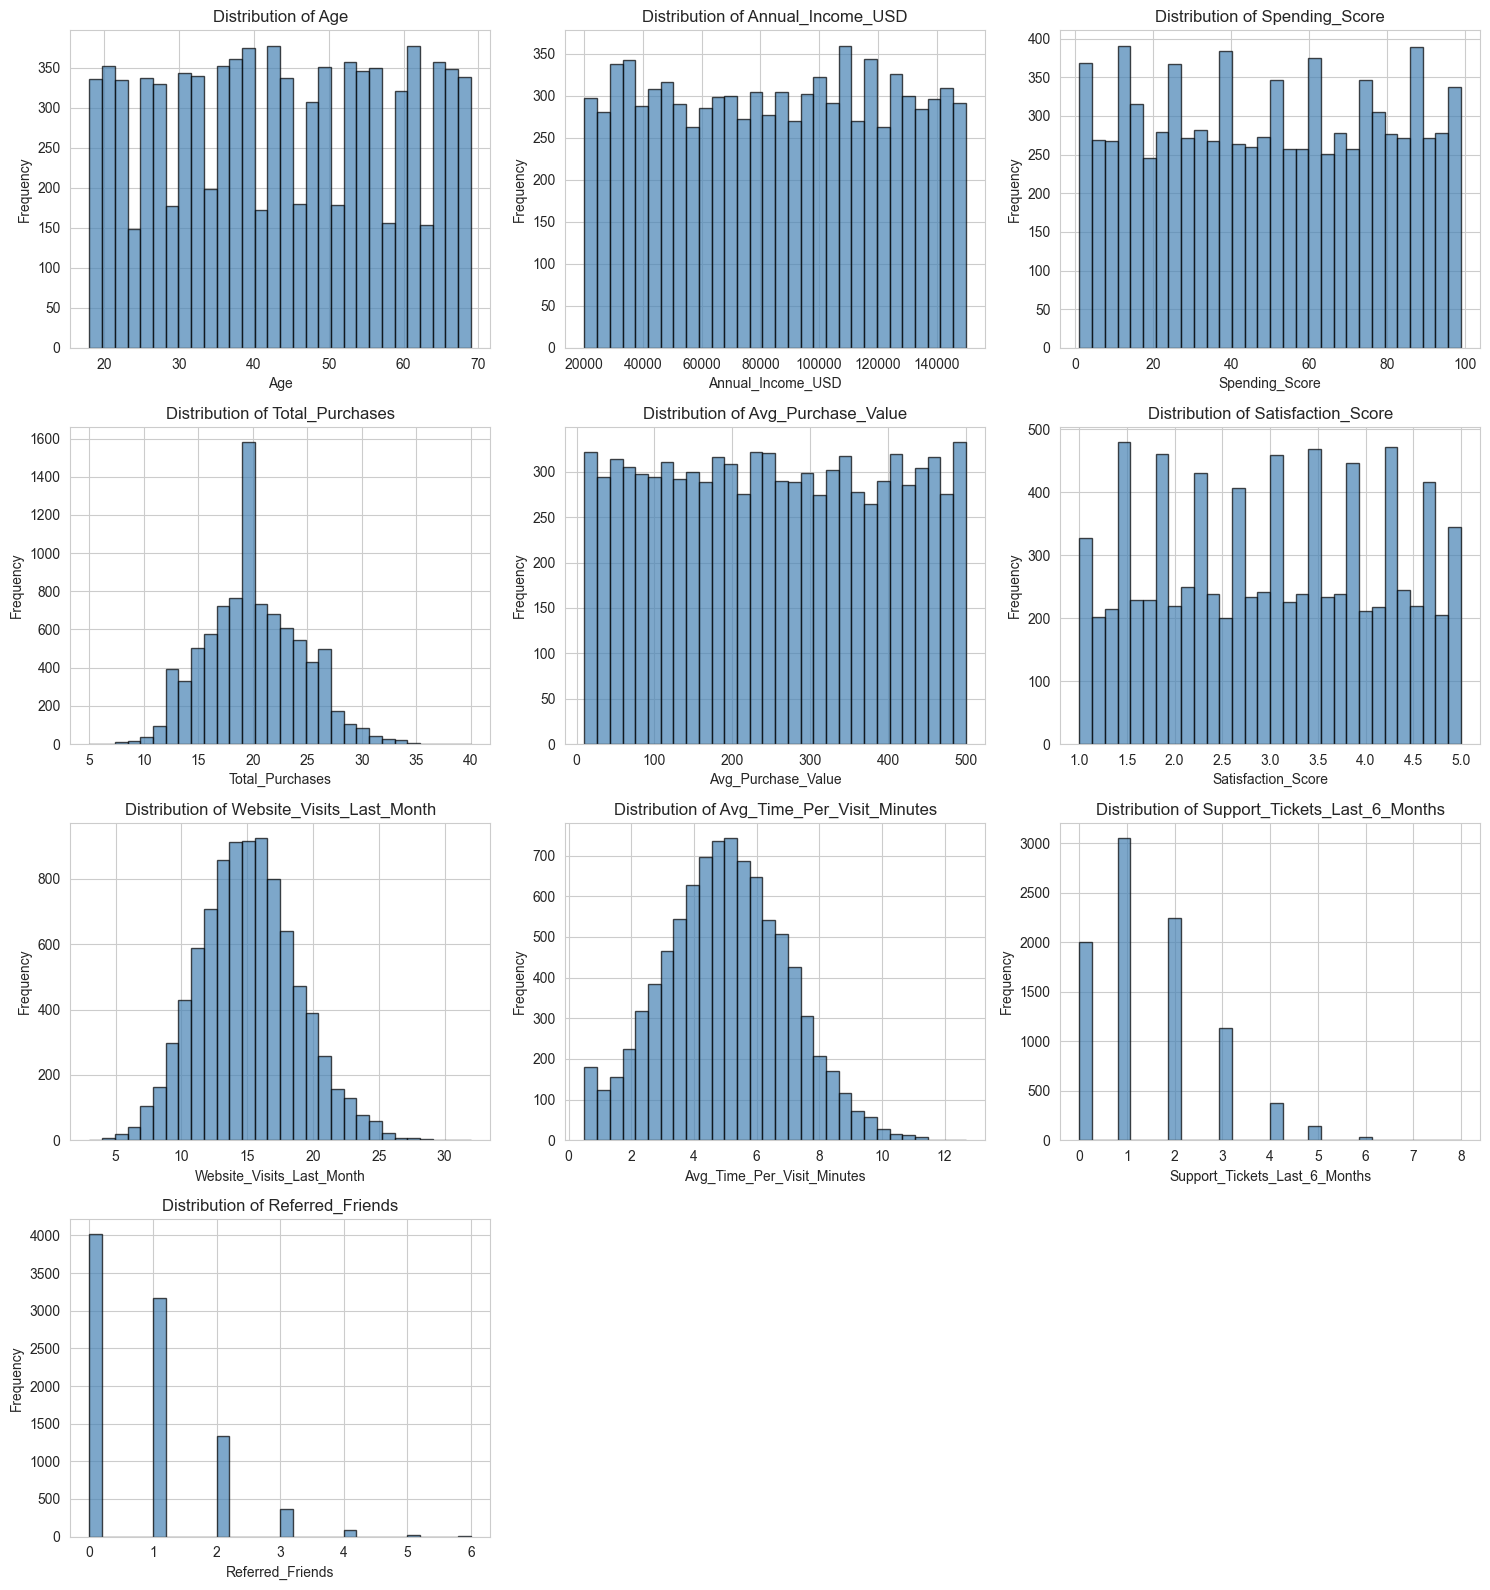

In [35]:
# Cell 9: Numerical features distribution
# Identify numerical columns (excluding CustomerID and target)

numerical_cols = ['Age', 'Annual_Income_USD', 'Spending_Score', 'Total_Purchases',
                  'Avg_Purchase_Value', 'Satisfaction_Score', 'Website_Visits_Last_Month',
                  'Avg_Time_Per_Visit_Minutes', 'Support_Tickets_Last_6_Months', 'Referred_Friends']

# Create histograms for all numerical features
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    
    # Plot histogram with kernel density estimate
    df[col].hist(ax=ax, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {col}')
    
# Remove empty subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The numerical feature distributions show a mix of uniform, normal, and skewed patterns:

- **Age, Annual Income, Spending Score, and Avg Purchase Value**
These variables appear relatively well distributed across their ranges, suggesting no extreme skewness or obvious data quality issues.

- **Total Purchases and Website Visits Last Month**
These features are approximately normally distributed, centered around moderate values. This suggests consistent purchasing and browsing behavior for most customers.

- **Avg Time Per Visit (Minutes)**
This variable shows a slightly right-skewed distribution, indicating that while most users spend a moderate amount of time per visit, a smaller group spends significantly longer on the website.

- **Support Tickets (Last 6 Months) and Referred Friends**
These features are heavily right-skewed, with most customers having low values and a small number showing high engagement or support needs.

**Implication:**
The dataset contains a mix of behavioral intensity levels, which is typical for e-commerce data and suitable for churn modeling.

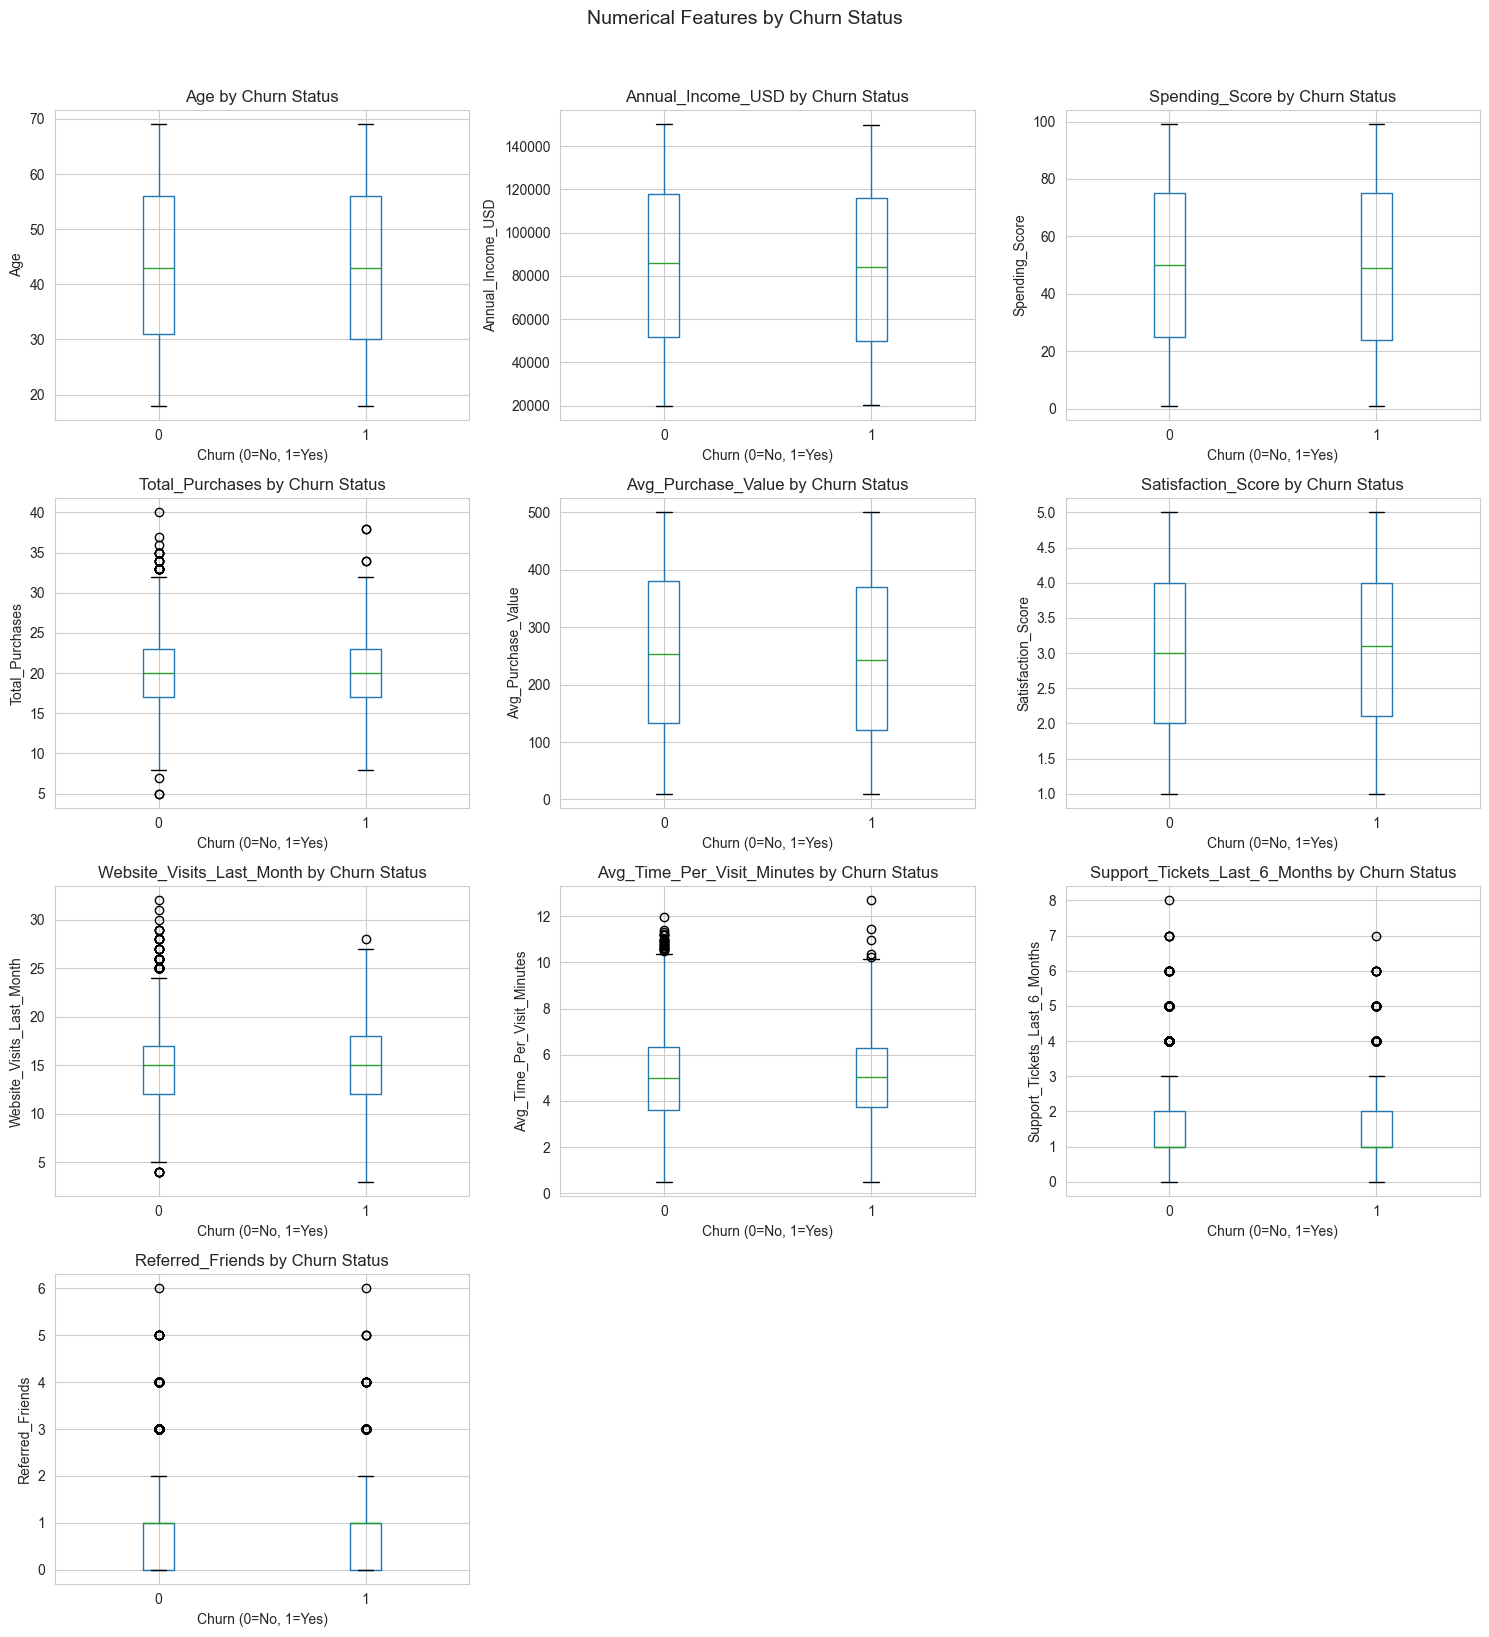

In [36]:
# Cell 10: Numerical features by churn status
# Compare distributions between churned and non-churned customers

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    
    # Create boxplot comparing churned vs non-churned
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_xlabel('Churn (0=No, 1=Yes)')
    ax.set_ylabel(col)
    ax.set_title(f'{col} by Churn Status')
    
# Remove empty subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Numerical Features by Churn Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Comparing numerical features across churned and non-churned customers reveals subtle but meaningful differences:

- Behavioral and engagement features (e.g. website visits, time per visit, support tickets) show more variation between churned and retained customers than pure demographic features.

- Demographic variables such as age and income show very similar distributions across churn groups, suggesting limited standalone predictive power.

**Implication:**
Churn appears to be driven more by customer behavior and engagement patterns rather than static demographic attributes.

## Categorical Feature Distribution

Let's analyze the distribution of categorical features and their relationship with churn.

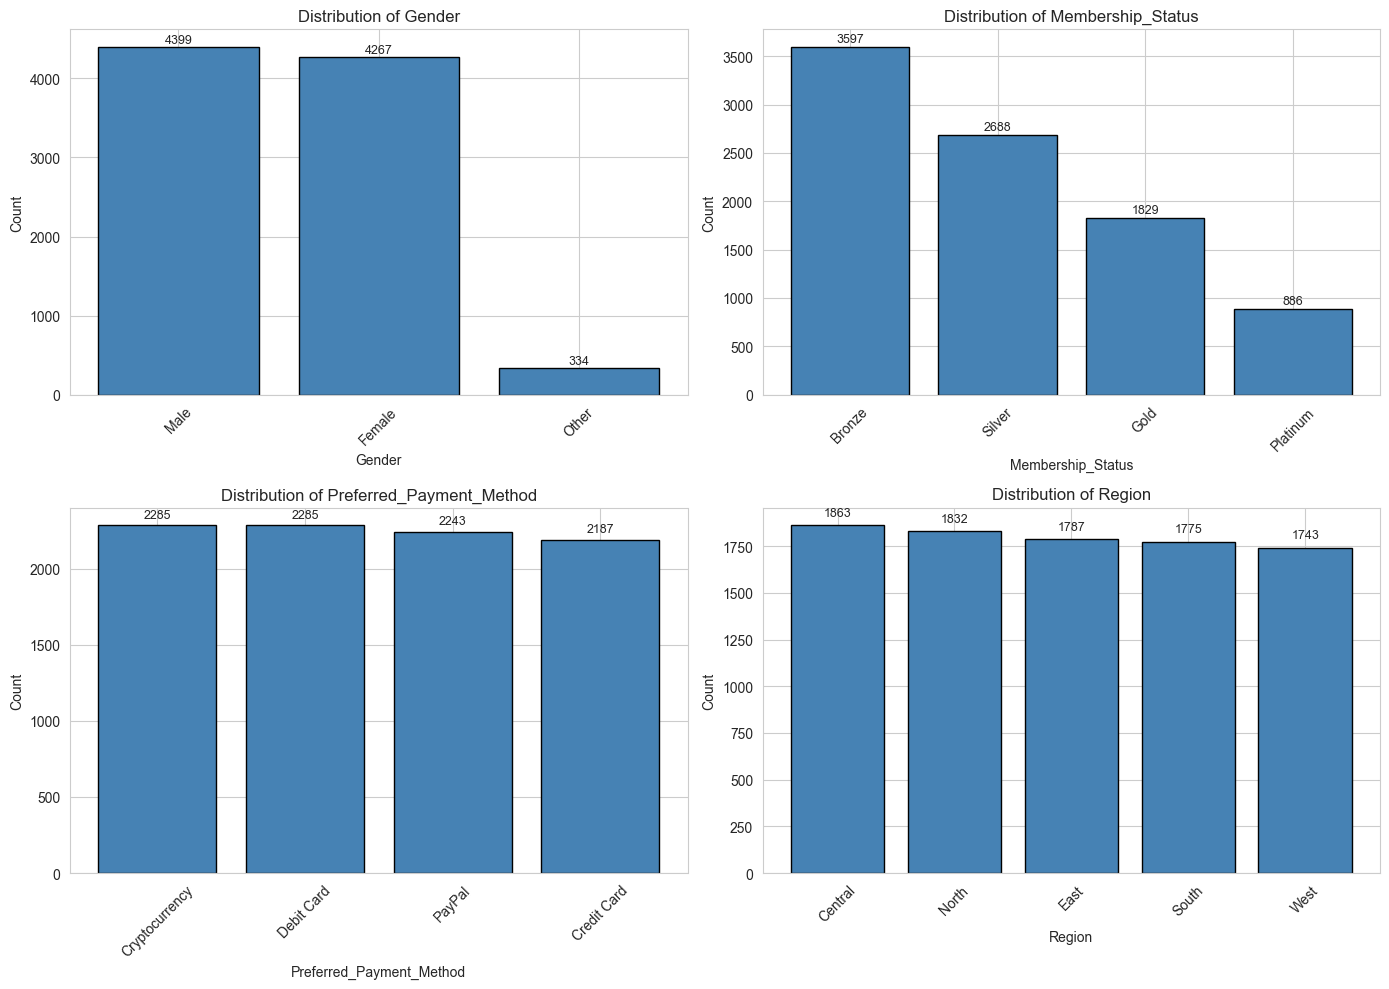

In [37]:
# Cell 11: Categorical features distribution
# Identify categorical columns (excluding CustomerID and date)

categorical_cols = ['Gender', 'Membership_Status', 'Preferred_Payment_Method', 'Region']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    
    # Count plot
    value_counts = df[col].value_counts()
    bars = ax.bar(value_counts.index, value_counts.values, color='steelblue', edgecolor='black')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)
    
    # Add count labels on bars
    for bar, count in zip(bars, value_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

The categorical variables show balanced and realistic distributions:

- Gender is relatively balanced between male and female customers.

- Membership status is skewed toward lower tiers (Bronze and Silver), with fewer Gold and Platinum users.

- Preferred payment methods are evenly distributed, with no dominant option.

- Regions are well balanced, reducing the risk of regional bias.

This balance supports fair model training without the need for aggressive reweighting.

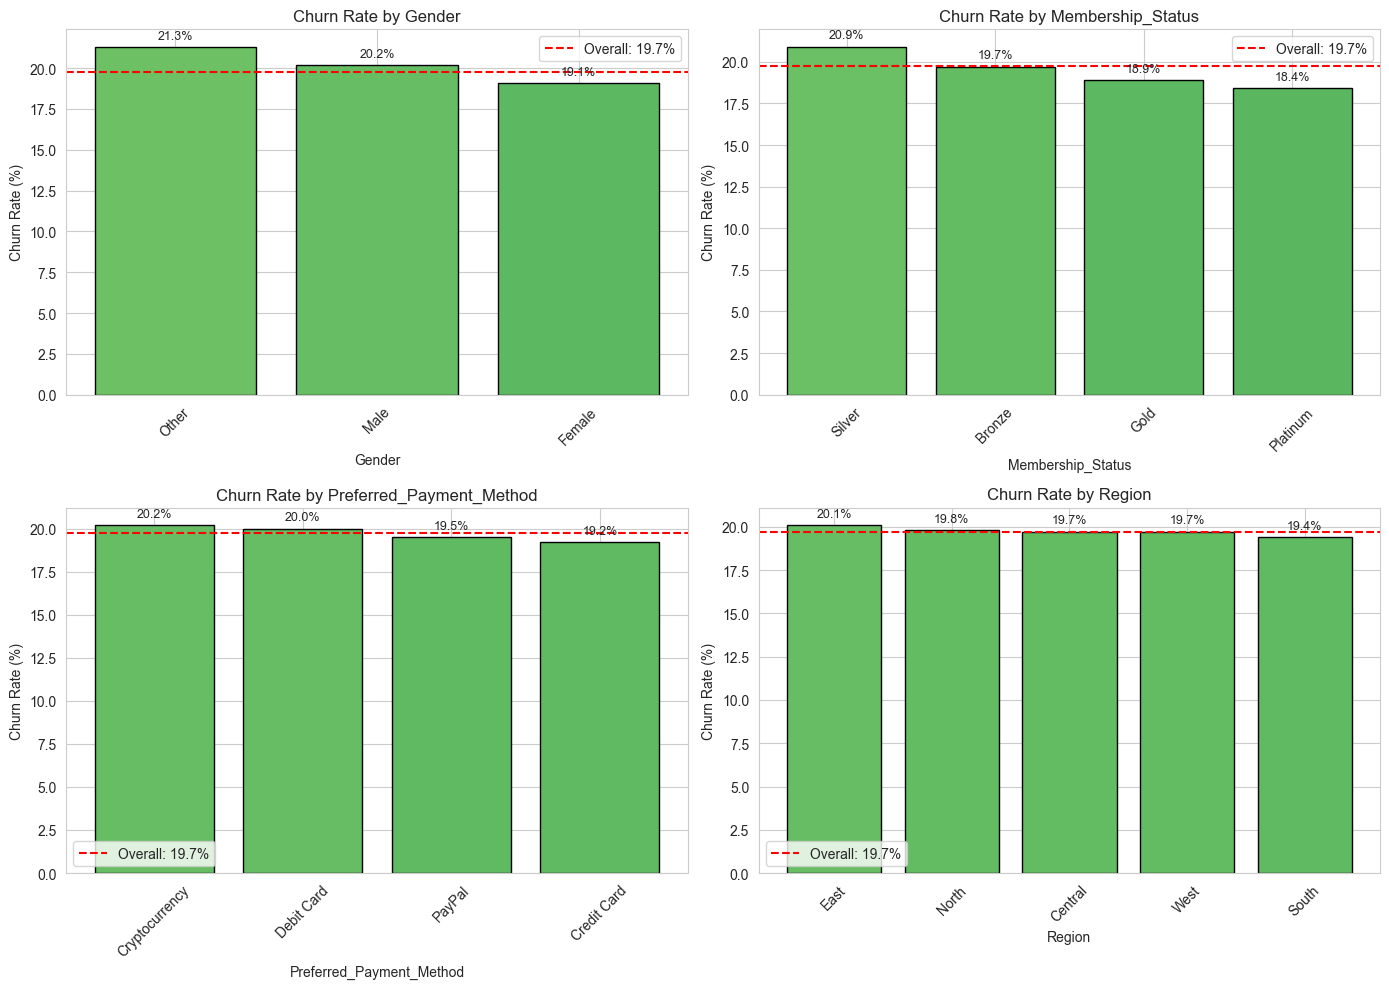

In [38]:
# Cell 12: Categorical features by churn status
# Analyze churn rate within each category

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    
    # Calculate churn rate by category
    churn_by_cat = df.groupby(col)['Churn'].agg(['sum', 'count'])
    churn_by_cat['churn_rate'] = (churn_by_cat['sum'] / churn_by_cat['count'] * 100).round(1)
    churn_by_cat = churn_by_cat.sort_values('churn_rate', ascending=False)
    
    # Create bar plot
    colors = plt.cm.RdYlGn_r(churn_by_cat['churn_rate'] / 100)
    bars = ax.bar(churn_by_cat.index, churn_by_cat['churn_rate'], color=colors, edgecolor='black')
    ax.set_xlabel(col)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_title(f'Churn Rate by {col}')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=churn_rate, color='red', linestyle='--', label=f'Overall: {churn_rate:.1f}%')
    ax.legend()
    
    # Add percentage labels
    for bar, rate in zip(bars, churn_by_cat['churn_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{rate}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

When examining churn rates by category:

- Churn rates are similar across gender groups, with only minor deviations from the overall churn rate (~19.7%).
- Higher-tier members (Gold and Platinum) show slightly lower churn rates, suggesting that loyalty programs may help retention.
- Churn rates are relatively consistent, indicating these variables alone are unlikely to be strong predictors

## Correlation Analysis

Let's examine the relationships between numerical features and the target variable.

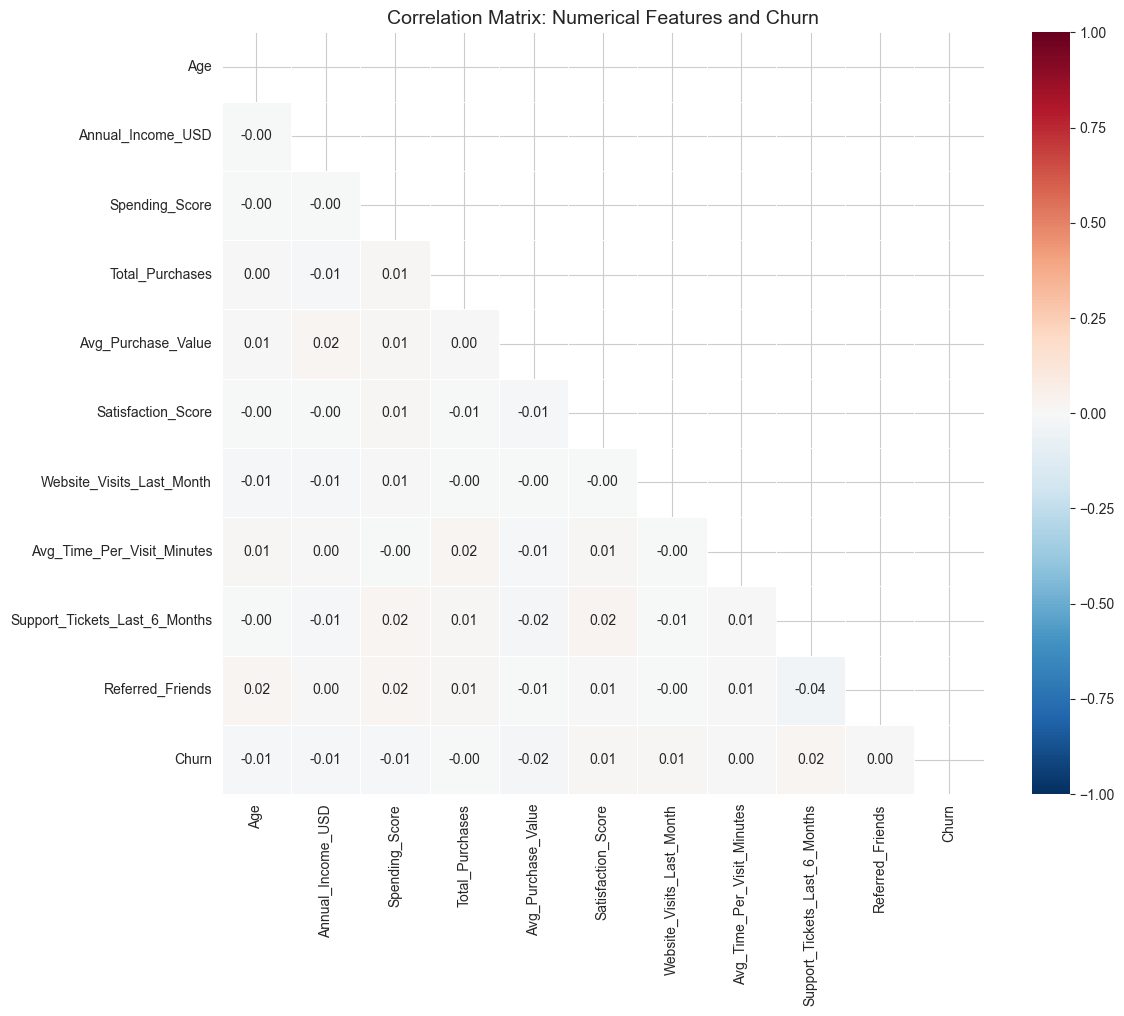

In [39]:
# Cell 13: Correlation heatmap
# Calculate correlations between numerical features and target

# Select numerical columns including target
corr_cols = numerical_cols + ['Churn']
correlation_matrix = df[corr_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True, linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Correlation Matrix: Numerical Features and Churn', fontsize=14)
plt.tight_layout()
plt.show()

The correlation matrix and feature–target correlation plot show:

- Very low linear correlations with churn across individual numerical features.

- No single feature strongly explains churn in isolation.

This is expected in churn problems, where:

- Churn is influenced by non-linear interactions

- Multiple weak signals combine to drive customer behavior

Feature Correlations with Churn (sorted by absolute value):
Avg_Purchase_Value                  -0.0232 ↓
Support_Tickets_Last_6_Months       +0.0161 ↑
Satisfaction_Score                  +0.0132 ↑
Annual_Income_USD                   -0.0126 ↓
Website_Visits_Last_Month           +0.0092 ↑
Age                                 -0.0090 ↓
Spending_Score                      -0.0090 ↓
Referred_Friends                    +0.0038 ↑
Total_Purchases                     -0.0016 ↓
Avg_Time_Per_Visit_Minutes          +0.0013 ↑


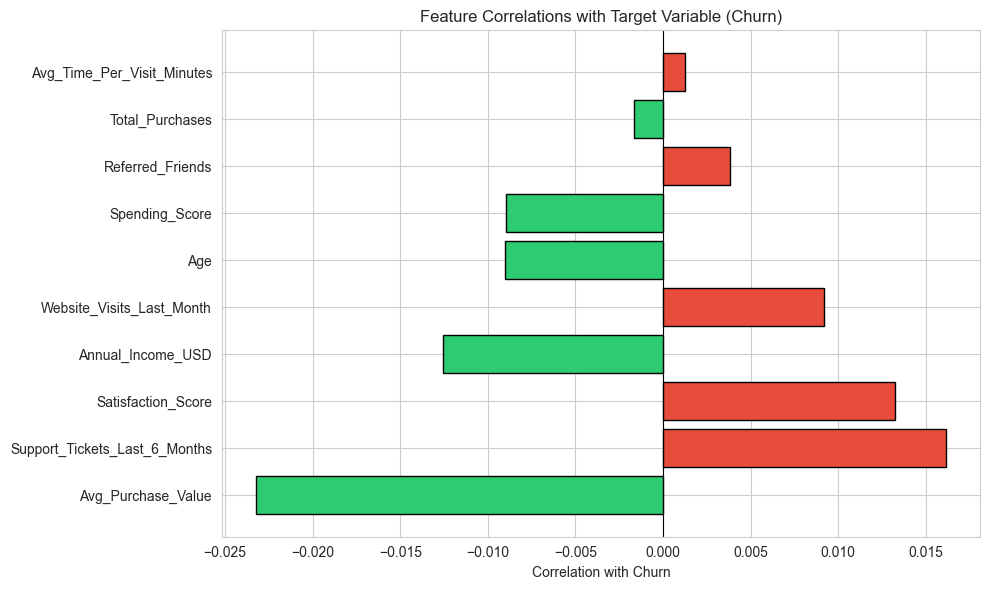

In [40]:
# Cell 14: Feature correlations with target (Churn)
# Identify most important features based on correlation

churn_correlations = correlation_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

print("Feature Correlations with Churn (sorted by absolute value):")
print("=" * 60)
for feature, corr in churn_correlations.items():
    direction = "↑" if corr > 0 else "↓"
    print(f"{feature:35} {corr:+.4f} {direction}")

# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in churn_correlations.values]
plt.barh(churn_correlations.index, churn_correlations.values, color=colors, edgecolor='black')
plt.xlabel('Correlation with Churn')
plt.title('Feature Correlations with Target Variable (Churn)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

The correlation analysis shows the linear relationship between each numerical feature and the churn variable.

Overall, all correlations with churn are very small in magnitude, with absolute values close to zero. This indicates that no single numerical feature has a strong linear relationship with churn.

Key observations include:

- Support_Tickets_Last_6_Months shows the highest positive correlation with churn, suggesting that customers who raise more support tickets are slightly more likely to churn.

- Satisfaction_Score and Website_Visits_Last_Month also show weak positive correlations, indicating that dissatisfaction or reduced engagement may contribute marginally to churn.

- Avg_Purchase_Value, Annual_Income_USD, Age, and Spending_Score show weak negative correlations, suggesting that higher-value or more established customers are slightly less likely to churn.

- Total_Purchases and Avg_Time_Per_Visit_Minutes exhibit near-zero correlations, implying minimal standalone linear influence.

## Summary
The exploratory data analysis confirms that the dataset is well-structured, realistic, and suitable for a customer churn prediction task.
What we found:
- The target variable is imbalanced, with approximately 80% retained customers and 20% churned customers, making accuracy an unreliable standalone metric.

- Demographic features (age, income, gender, region) show little differentiation between churned and non-churned customers.

- Behavioral and engagement features (website visits, time per visit, support tickets, satisfaction score) exhibit more meaningful variation across churn groups.

- Churn rates across categorical variables (gender, payment method, region) remain close to the overall churn rate, while higher membership tiers show slightly lower churn, suggesting loyalty effects.

- Correlation analysis reveals no strong linear relationship between individual features and churn, indicating that churn is driven by complex, multi-factor interactions rather than single variables.

Next steps:
- Handle class imbalance (class weights or resampling)
- Encode categorical variables
- Add features from the date column
- Apply the Baseline model to the dataset

## Data Preparation

Prepare the data for modeling by splitting into train, validation, and test sets.

In [41]:
# Cell 15: Data preparation and train/validation/test split

from sklearn.model_selection import train_test_split

# Define features and target
# Exclude CustomerID (identifier) and Last_Purchase_Date (needs feature engineering)
feature_cols = ['Age', 'Gender', 'Annual_Income_USD', 'Spending_Score', 
                'Membership_Status', 'Preferred_Payment_Method', 'Region',
                'Total_Purchases', 'Avg_Purchase_Value', 'Satisfaction_Score',
                'Website_Visits_Last_Month', 'Avg_Time_Per_Visit_Minutes',
                'Support_Tickets_Last_6_Months', 'Referred_Friends']

X = df[feature_cols].copy()
y = df['Churn'].copy()

# First split: 80% train+validation, 20% test (held out for production simulation)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Second split: 75% train, 25% validation (of the 80%)
# This gives us: 60% train, 20% validation, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Dataset Split Summary:")
print("=" * 50)
print(f"Training set:   {len(X_train):5} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val):5} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:       {len(X_test):5} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTotal:          {len(X):5} samples")

print("\nChurn distribution in each split:")
print(f"Train:      {y_train.mean()*100:.1f}% churned")
print(f"Validation: {y_val.mean()*100:.1f}% churned")
print(f"Test:       {y_test.mean()*100:.1f}% churned")

Dataset Split Summary:
Training set:    5400 samples (60.0%)
Validation set:  1800 samples (20.0%)
Test set:        1800 samples (20.0%)

Total:           9000 samples

Churn distribution in each split:
Train:      19.7% churned
Validation: 19.7% churned
Test:       19.7% churned


In [42]:
# Cell 16: Export dataset sample for deliverable (< 5MB)
# Save a stratified sample of the dataset

# Create data directory if it doesn't exist
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
os.makedirs(data_dir, exist_ok=True)

# Save full dataset for project use
full_data_path = os.path.join(data_dir, 'online_retail_churn.csv')
df.to_csv(full_data_path, index=False)
print(f"Full dataset saved to: {full_data_path}")

# Create a smaller sample for deliverable (1000 rows, stratified)
sample_size = 1000
df_sample = df.groupby('Churn', group_keys=False).apply(
    lambda x: x.sample(n=int(sample_size * len(x) / len(df)), random_state=42)
)
sample_path = os.path.join(data_dir, 'dataset_sample.csv')
df_sample.to_csv(sample_path, index=False)

# Check file size
sample_size_mb = os.path.getsize(sample_path) / (1024 * 1024)
print(f"\nDataset sample saved to: {sample_path}")
print(f"Sample size: {len(df_sample)} rows")
print(f"File size: {sample_size_mb:.2f} MB")

Full dataset saved to: /Users/matiascam/Documents/2_Education/ESMT/ml-production/data/online_retail_churn.csv

Dataset sample saved to: /Users/matiascam/Documents/2_Education/ESMT/ml-production/data/dataset_sample.csv
Sample size: 999 rows
File size: 0.11 MB


## Baseline Model Evaluation

Evaluate the baseline model on training and validation sets.

In [43]:
# Cell 17: Import and fit the baseline model
# Add src directory to path for importing baseline module

import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

from baseline import BaselineModel, print_metrics

# Initialize and fit baseline model
baseline = BaselineModel()
baseline.fit(X_train, y_train)

print("Baseline Model Fitted")
print("=" * 50)
print(f"Model: {baseline}")
print(f"Class distribution in training data: {baseline.class_distribution}")
print(f"Most frequent class: {baseline.most_frequent_class}")

Baseline Model Fitted
Model: BaselineModel(most_frequent_class=0)
Class distribution in training data: {np.int64(0): np.int64(4334), np.int64(1): np.int64(1066)}
Most frequent class: 0


In [44]:
# Cell 18: Evaluate baseline on training and validation sets

# Evaluate on training set
train_metrics = baseline.evaluate(X_train, y_train)
print_metrics(train_metrics, "Training Set")

# Evaluate on validation set
val_metrics = baseline.evaluate(X_val, y_val)
print_metrics(val_metrics, "Validation Set")


Training Set Metrics:
Accuracy:  0.8026
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5000

Confusion Matrix:
[[4334    0]
 [1066    0]]

Validation Set Metrics:
Accuracy:  0.8028
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5000

Confusion Matrix:
[[1445    0]
 [ 355    0]]


In [45]:
# Cell 19: Baseline metrics summary table

# Create summary DataFrame
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training': [
        train_metrics['accuracy'],
        train_metrics['precision'],
        train_metrics['recall'],
        train_metrics['f1_score'],
        train_metrics['roc_auc']
    ],
    'Validation': [
        val_metrics['accuracy'],
        val_metrics['precision'],
        val_metrics['recall'],
        val_metrics['f1_score'],
        val_metrics['roc_auc']
    ]
})

print("\nBaseline Model - Metrics Summary:")
print("=" * 50)
print(metrics_summary.to_string(index=False))

# Save metrics to file for deliverable
metrics_path = os.path.join(data_dir, 'baseline_metrics.csv')
metrics_summary.to_csv(metrics_path, index=False)
print(f"\nMetrics saved to: {metrics_path}")


Baseline Model - Metrics Summary:
   Metric  Training  Validation
 Accuracy  0.802593    0.802778
Precision  0.000000    0.000000
   Recall  0.000000    0.000000
 F1-Score  0.000000    0.000000
  ROC-AUC  0.500000    0.500000

Metrics saved to: /Users/matiascam/Documents/2_Education/ESMT/ml-production/data/baseline_metrics.csv


## What does this mean?

The baseline just says "no one will churn" for every customer. 

- Gets 80% accuracy because 80% of customers actually don't churn
- But recall = 0 means it catches zero actual churners
- ROC-AUC = 0.5 is basically random guessing

Bottom line: any real model needs to beat this. We need actual recall to identify churners.